# Mode0 LFP + Sensor Free-Behavior State Analysis

This notebook analyzes continuous Mode0 `lfp.edf` and `sensor.edf` files.

Workflow:
- Load Mode0 LFP and sensor EDF files.
- Treat LFP values `<= -1000` and sensor values `<= -10` as packet/data loss, then linearly interpolate them.
- For `sensor.edf`, use the Mode3-compatible rule: build one missing-data mask from sensor channel 0, then interpolate every sensor channel with that same mask.
- Use the first three accelerometer channels to classify putative behavioral state: `motion`, `rest`, and `sleep`.
- Use the naturally aligned IMU and LFP time bases to compare state labels with LFP spectrograms.
- Plot state-aligned LFP spectrograms and band-power traces with configurable median re-reference and channel selection.

Note: sleep is inferred from sustained low accelerometer activity only, so it should be interpreted as `putative sleep` unless confirmed by additional signals or video.


## Imports And User Configuration

This cell imports the analysis packages, finds the repository root, and defines the main `CONFIG` dictionary used by the rest of the notebook.

Key parameters you may want to edit:
- `lfp_path` and `sensor_path`: choose the Mode0 EDF pair to analyze.
- `lfp_missing_threshold`: LFP missing-data threshold, currently `-1000`.
- `sensor_missing_threshold`: sensor missing-data threshold, currently `-10`.
- `sensor_missing_mask_mode` and `sensor_missing_mask_channel`: Mode3-compatible sensor cleanup uses channel 0 to detect packet loss, then interpolates all sensor channels with the same mask.
- `selected_lfp_channels`, `median_reference`, `lfp_display_mode`, and `lfp_single_display_channel`: control which LFP signal is displayed and whether median re-reference is applied.
- `spectrogram_window_s`, `spectrogram_overlap_s`, `lfp_fmax_hz`, `spectrogram_cmap`, `spectrogram_vmin_percentile`, `spectrogram_vmax_percentile`, `lfp_bands`, and `band_power_smooth_s`: control frequency analysis and band-power plotting.
- `activity_epoch_s`, `activity_step_s`, `accel_highpass_hz`, `motion_quantile`, and `rest_to_sleep_min_duration_s`: control IMU-based motion/rest/sleep classification. Sleep is defined as rest lasting at least this duration, default `40 s`.
- `sleep_stage_delta_band_hz`, `sleep_stage_theta_band_hz`, `rem_theta_delta_quantile`, `manual_rem_theta_delta_threshold`, and `min_sleep_epochs_for_rem_scoring`: control LFP-based NREM/REM subdivision inside IMU-defined sleep epochs.


In [57]:
import os
import re
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy import signal

try:
    import pyedflib
except ImportError as exc:
    raise ImportError("This notebook requires pyedflib to read EDF files.") from exc


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "Protocol").exists() and (candidate / "DataAnaysisScirpt").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root.")


REPO_ROOT = find_repo_root(Path.cwd())
MODE0_DIR = REPO_ROOT / "DataAnaysisScirpt" / "Daily_LFP_Rhythm_GUI" / "legacy_mode0_analysis"

CONFIG = {
    "lfp_path": "F:\\FormalData\\ExperimentData\\BW08\\Neural\\Mode0\\2026-04-02\\2026-04-02-07-34-56lfp.edf",
    "sensor_path": "F:\\FormalData\\ExperimentData\\BW08\\Neural\\Mode0\\2026-04-02\\2026-04-02-07-34-56sensor.edf",
    "lfp_missing_threshold": -1000.0,
    "sensor_missing_threshold": -10.0,
    "sensor_missing_mask_mode": "mode3_sensor_channel0",
    "sensor_missing_mask_channel": 0,
    "lfp_missing_mask_mode": "per_channel",
    "selected_lfp_channels": list(range(16)),
    "median_reference": True,
    "lfp_display_mode": "mean_selected",
    "lfp_single_display_channel": 0,
    "lfp_fmax_hz": 50.0,
    "spectrogram_window_s": 4.0,
    "spectrogram_overlap_s": 3.0,
    "spectrogram_cmap": "jet",
    "spectrogram_vmin_percentile": 5.0,
    "spectrogram_vmax_percentile": 99.5,
    "spectrogram_show_colorbar": False,
    "spectrogram_state_bar_height": 0.22,
    "band_power_smooth_s": 5.0,
    "lfp_bands": [
        ("delta", 1.0, 4.0),
        ("theta", 4.0, 12.0),
        ("alpha_beta", 12.0, 30.0),
        ("low_gamma", 30.0, 55.0),
        ("high_gamma", 65.0, 120.0),
    ],
    "accel_label_candidates": ["AcclX", "AcclY", "AcclZ", "AccelX", "AccelY", "AccelZ"],
    "activity_epoch_s": 5.0,
    "activity_step_s": 5.0,
    "accel_highpass_hz": 0.25,
    "motion_quantile": 0.70,
    "rest_to_sleep_min_duration_s": 40.0,
    "manual_motion_threshold": None,
    "sleep_stage_delta_band_hz": (0.5, 4.0),
    "sleep_stage_theta_band_hz": (6.0, 10.0),
    "sleep_stage_welch_window_s": 4.0,
    "rem_theta_delta_quantile": 0.75,
    "manual_rem_theta_delta_threshold": 1.75,
    "min_sleep_epochs_for_rem_scoring": 3,
}

print(f"Repository root: {REPO_ROOT}")
print(f"Mode0 analysis directory: {MODE0_DIR}")
print(f"LFP path: {CONFIG['lfp_path']} | exists={Path(CONFIG['lfp_path']).exists()}")
print(f"Sensor path: {CONFIG['sensor_path']} | exists={Path(CONFIG['sensor_path']).exists()}")


Repository root: E:\SyncFoldFromMyMac
Mode0 analysis directory: Daily_LFP_Rhythm_GUI/legacy_mode0_analysis
LFP path: F:\FormalData\ExperimentData\BW08\Neural\Mode0\2026-04-02\2026-04-02-07-34-56lfp.edf | exists=True
Sensor path: F:\FormalData\ExperimentData\BW08\Neural\Mode0\2026-04-02\2026-04-02-07-34-56sensor.edf | exists=True


## EDF Reading And Missing-Data Helper Functions

This cell defines reusable helper functions for EDF loading, timestamp reconstruction, missing-data interpolation, and accelerometer-channel discovery.

Important behavior and parameters:
- `read_edf_matrix()` reads all EDF channels into a `channels x samples` matrix and reconstructs absolute time from `EndTimestamp(ms)` when present.
- `interpolate_1d_bad_values()` fills bad samples by linear interpolation and keeps the original sample count unchanged.
- `clean_missing_matrix()` supports `per_channel` cleanup and the Mode3-compatible `mode3_sensor_channel0` cleanup.
- `threshold` is supplied separately for LFP and sensor data from `CONFIG`.
- `source_channel` controls which channel defines the shared missing-data mask for sensor EDF cleanup; the default is channel 0.
- `find_accel_indices()` searches channel labels for X/Y/Z accelerometer channels, with fallback names from `accel_label_candidates`.


In [58]:
def parse_end_timestamp_ms(edf_reader):
    try:
        _, _, annotations = edf_reader.readAnnotations()
    except Exception:
        return np.nan
    for annotation in annotations:
        match = re.search(r"EndTimestamp\(ms\)=([0-9.]+)", str(annotation))
        if match:
            return float(match.group(1))
    return np.nan


def read_edf_matrix(path):
    path = Path(path)
    reader = pyedflib.EdfReader(str(path))
    try:
        labels = list(reader.getSignalLabels())
        fs = np.asarray([reader.getSampleFrequency(ch) for ch in range(reader.signals_in_file)], dtype=float)
        n_samples = np.asarray(reader.getNSamples(), dtype=int)
        if not np.allclose(fs, fs[0]):
            raise ValueError(f"All EDF channels must share one sampling rate. Got {fs}.")
        if not np.all(n_samples == n_samples[0]):
            raise ValueError(f"All EDF channels must share one sample count. Got {n_samples}.")
        data = np.vstack([reader.readSignal(ch) for ch in range(reader.signals_in_file)]).astype(float)
        end_ts_ms = parse_end_timestamp_ms(reader)
    finally:
        reader.close()

    duration_ms = 1000.0 * data.shape[1] / fs[0]
    start_ts_ms = end_ts_ms - duration_ms if np.isfinite(end_ts_ms) else 0.0
    time_s_abs = start_ts_ms / 1000.0 + np.arange(data.shape[1], dtype=float) / fs[0]
    return {
        "path": path,
        "labels": labels,
        "fs": float(fs[0]),
        "data": data,
        "end_ts_ms": end_ts_ms,
        "start_ts_ms": start_ts_ms,
        "time_s_abs": time_s_abs,
    }


def interpolate_1d_bad_values(x, bad_mask):
    x = np.asarray(x, dtype=float)
    bad_mask = np.asarray(bad_mask, dtype=bool)
    if not np.any(bad_mask):
        return x.copy()
    good_mask = ~bad_mask
    out = x.copy()
    if np.sum(good_mask) == 0:
        out[:] = 0.0
        return out
    sample_idx = np.arange(x.size)
    out[bad_mask] = np.interp(sample_idx[bad_mask], sample_idx[good_mask], x[good_mask])
    return out


def clean_missing_matrix(data, threshold=-1000.0, mask_mode="per_channel", source_channel=0):
    """Interpolate missing samples without changing length.

    `mode3_sensor_channel0` reproduces the Mode3 sensor EDF cleanup:
    detect bad samples from sensor channel 0, then apply that same bad-sample
    mask to every sensor channel before linear interpolation.
    """
    data = np.asarray(data, dtype=float)
    cleaned = np.empty_like(data, dtype=float)
    loss_fraction = []

    if mask_mode in {"shared_first_channel", "mode3_sensor_channel0"}:
        source_channel = int(source_channel)
        if not 0 <= source_channel < data.shape[0]:
            raise ValueError(f"source_channel={source_channel} is outside data channel range.")
        shared_bad = data[source_channel] <= threshold
        for ch in range(data.shape[0]):
            cleaned[ch] = interpolate_1d_bad_values(data[ch], shared_bad)
            loss_fraction.append(float(np.mean(shared_bad)))
    elif mask_mode == "per_channel":
        for ch in range(data.shape[0]):
            bad = data[ch] <= threshold
            cleaned[ch] = interpolate_1d_bad_values(data[ch], bad)
            loss_fraction.append(float(np.mean(bad)))
    else:
        raise ValueError("mask_mode must be 'per_channel', 'shared_first_channel', or 'mode3_sensor_channel0'.")

    return cleaned, np.asarray(loss_fraction, dtype=float)


def find_accel_indices(labels, candidates):
    lowered = [label.lower() for label in labels]
    wanted_axes = ["x", "y", "z"]
    out = []
    for axis in wanted_axes:
        matches = []
        for idx, label in enumerate(lowered):
            is_acc = ("accl" in label) or ("accel" in label) or ("acceler" in label)
            if is_acc and axis in label:
                matches.append(idx)
        if matches:
            out.append(matches[0])
    if len(out) == 3:
        return out

    fallback = []
    for name in candidates[:3]:
        name_l = name.lower()
        for idx, label in enumerate(lowered):
            if name_l in label:
                fallback.append(idx)
                break
    if len(fallback) == 3:
        return fallback
    raise ValueError(f"Could not find three accelerometer channels in labels: {labels}")


def seconds_to_minutes(x):
    return np.asarray(x, dtype=float) / 60.0


## Load And Clean EDF Data

This cell loads the LFP and sensor EDF files, applies missing-data interpolation, reconstructs a shared time axis, and prints basic quality-control information.

Parameters controlled by `CONFIG`:
- `lfp_path` and `sensor_path`: input files.
- `lfp_missing_threshold`: values at or below this are treated as missing in LFP, currently `-1000`.
- `sensor_missing_threshold`: values at or below this are treated as missing in sensor channels, currently `-10`.
- `lfp_missing_mask_mode`: usually `per_channel`, meaning each LFP channel gets its own missing mask.
- `sensor_missing_mask_mode`: default `mode3_sensor_channel0`, matching Mode3 sensor EDF handling.
- `sensor_missing_mask_channel`: default `0`, usually `AcclX`; this channel defines missing samples for all sensor channels.

The printed `LFP - Sensor start/end delta` values are a sanity check for the assumption that Mode0 IMU and LFP streams are naturally aligned.


In [59]:
lfp = read_edf_matrix(CONFIG["lfp_path"])
sensor_edf = read_edf_matrix(CONFIG["sensor_path"])

lfp_clean, lfp_loss_fraction = clean_missing_matrix(
    lfp["data"],
    threshold=CONFIG["lfp_missing_threshold"],
    mask_mode=CONFIG["lfp_missing_mask_mode"],
)
sensor_clean, sensor_loss_fraction = clean_missing_matrix(
    sensor_edf["data"],
    threshold=CONFIG["sensor_missing_threshold"],
    mask_mode=CONFIG["sensor_missing_mask_mode"],
    source_channel=CONFIG["sensor_missing_mask_channel"],
)

common_start_s = max(lfp["time_s_abs"][0], sensor_edf["time_s_abs"][0])
lfp_t_s = lfp["time_s_abs"] - common_start_s
sensor_t_s = sensor_edf["time_s_abs"] - common_start_s

print("LFP")
print(f"  missing threshold: <= {CONFIG['lfp_missing_threshold']}")
print(f"  labels: {lfp['labels']}")
print(f"  fs: {lfp['fs']:.3f} Hz | channels: {lfp_clean.shape[0]} | samples: {lfp_clean.shape[1]}")
print(f"  end timestamp: {lfp['end_ts_ms']:.3f} ms | start timestamp: {lfp['start_ts_ms']:.3f} ms")
print(f"  data loss per channel (%): {np.round(100 * lfp_loss_fraction, 4)}")

print("Sensor")
print(f"  missing threshold: <= {CONFIG['sensor_missing_threshold']}")
print(f"  missing cleanup: {CONFIG['sensor_missing_mask_mode']} | source channel: {CONFIG['sensor_missing_mask_channel']} ({sensor_edf['labels'][CONFIG['sensor_missing_mask_channel']]})")
print(f"  labels: {sensor_edf['labels']}")
print(f"  fs: {sensor_edf['fs']:.3f} Hz | channels: {sensor_clean.shape[0]} | samples: {sensor_clean.shape[1]}")
print(f"  end timestamp: {sensor_edf['end_ts_ms']:.3f} ms | start timestamp: {sensor_edf['start_ts_ms']:.3f} ms")
print(f"  data loss per channel (%): {np.round(100 * sensor_loss_fraction, 4)}")

start_delta_ms = 1000.0 * (lfp["time_s_abs"][0] - sensor_edf["time_s_abs"][0])
end_delta_ms = 1000.0 * (lfp["time_s_abs"][-1] - sensor_edf["time_s_abs"][-1])
print(f"LFP - Sensor start delta: {start_delta_ms:.3f} ms")
print(f"LFP - Sensor end delta:   {end_delta_ms:.3f} ms")


LFP
  missing threshold: <= -1000.0
  labels: ['Ch0', 'Ch1', 'Ch2', 'Ch3', 'Ch4', 'Ch5', 'Ch6', 'Ch7', 'Ch8', 'Ch9', 'Ch10', 'Ch11', 'Ch12', 'Ch13', 'Ch14', 'Ch15']
  fs: 1000.000 Hz | channels: 16 | samples: 1801000
  end timestamp: 120539294.000 ms | start timestamp: 118738294.000 ms
  data loss per channel (%): [0.0149 0.0096 0.0104 0.0097 0.0279 0.0109 0.0099 0.0099 0.0101 0.0099
 0.0098 0.0102 0.0096 0.0105 0.0107 0.0112]
Sensor
  missing threshold: <= -10.0
  missing cleanup: mode3_sensor_channel0 | source channel: 0 (AcclX)
  labels: ['AcclX', 'AcclY', 'AcclZ', 'GryoX', 'GryoY', 'GryoZ', 'RSOC', 'Battery_STAT', 'Battery_voltage', 'UpdateFlag']
  fs: 250.000 Hz | channels: 10 | samples: 450250
  end timestamp: 120539294.000 ms | start timestamp: 118738294.000 ms
  data loss per channel (%): [0.0096 0.0096 0.0096 0.0096 0.0096 0.0096 0.0096 0.0096 0.0096 0.0096]
LFP - Sensor start delta: 0.000 ms
LFP - Sensor end delta:   3.000 ms


## Classify Acceleration-Based Behavioral States

This cell uses the cleaned three-axis accelerometer signal to estimate free-behavior state over time. It high-pass filters acceleration to emphasize movement-related dynamics, computes epoch-wise dynamic acceleration RMS, then labels each epoch.

State definitions:
- `motion`: high dynamic acceleration.
- `rest`: non-motion epochs before they have persisted long enough to count as sleep.
- `sleep`: continuous `rest` lasting at least `rest_to_sleep_min_duration_s`, default `40 s`.

Parameters controlled by `CONFIG`:
- `accel_label_candidates`: fallback accelerometer label names if automatic X/Y/Z matching fails.
- `accel_highpass_hz`: high-pass cutoff used to remove slow gravity/posture components before RMS scoring.
- `activity_epoch_s`: window length for state classification.
- `activity_step_s`: step size between classification windows.
- `motion_quantile`: adaptive percentile for motion threshold.
- `manual_motion_threshold`: set this to a number if you want a fixed motion threshold instead of the adaptive quantile.
- `rest_to_sleep_min_duration_s`: minimum continuous rest duration required to relabel rest as sleep.

The output figure shows raw accelerometer traces, the activity score with the motion threshold, and the IMU-derived motion/rest/sleep timeline. NREM/REM are not assigned here; they are assigned later from LFP only within sleep epochs.


Accelerometer channels: [(0, 'AcclX'), (1, 'AcclY'), (2, 'AcclZ')]
Motion threshold: 0.0234666
Rest-to-sleep minimum duration: 40 s
 sleep:   243 epochs | approx 20.25 min
  rest:     9 epochs | approx 0.75 min
motion:   108 epochs | approx 9.00 min


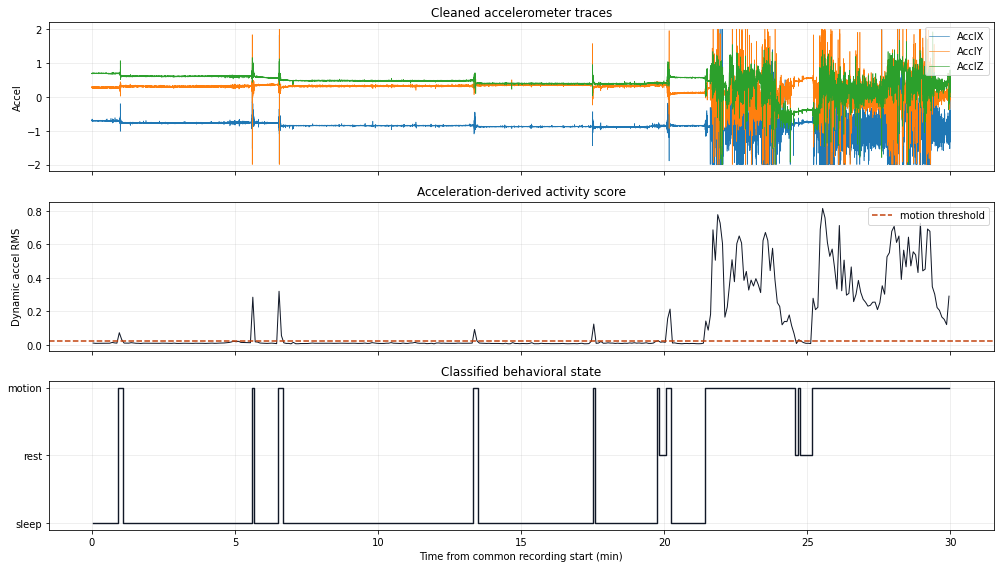

In [60]:
STATE_ORDER = ["sleep", "rest", "motion"]
STATE_TO_CODE = {"sleep": 0, "rest": 1, "motion": 2}
STATE_COLORS = {"sleep": "#1f4e79", "nrem": "#1f4e79", "rem": "#7c3aed", "rest": "#7a7f38", "motion": "#c2410c"}


def highpass_accel(accel, fs, cutoff_hz):
    accel = np.asarray(accel, dtype=float)
    if cutoff_hz <= 0 or accel.shape[1] < int(fs * 4):
        return accel - np.median(accel, axis=1, keepdims=True)
    cutoff = min(cutoff_hz, fs * 0.4)
    b, a = signal.butter(2, cutoff, btype="highpass", fs=fs)
    return signal.filtfilt(b, a, accel, axis=-1)


def epoch_feature(values, time_s, epoch_s, step_s):
    values = np.asarray(values, dtype=float)
    start = float(time_s[0])
    stop = float(time_s[-1])
    starts = np.arange(start, stop - epoch_s + step_s * 0.5, step_s)
    rows = []
    for t0 in starts:
        t1 = t0 + epoch_s
        mask = (time_s >= t0) & (time_s < t1)
        if not np.any(mask):
            rows.append(np.nan)
        else:
            segment = values[mask]
            rows.append(float(np.sqrt(np.mean(segment ** 2))))
    starts = np.asarray(starts, dtype=float)
    stops = starts + epoch_s
    centers = starts + epoch_s / 2.0
    return starts, stops, centers, np.asarray(rows, dtype=float)


def apply_sustained_rest_to_sleep_rule(initial_state, epoch_step_s, min_duration_s):
    states = np.array(initial_state, dtype=object)
    rest_mask = states == "rest"
    min_epochs = max(1, int(np.ceil(min_duration_s / epoch_step_s)))
    idx = 0
    while idx < rest_mask.size:
        if not rest_mask[idx]:
            idx += 1
            continue
        start = idx
        while idx < rest_mask.size and rest_mask[idx]:
            idx += 1
        if idx - start >= min_epochs:
            states[start:idx] = "sleep"
    return states


def classify_accel_states(accel, time_s, fs, cfg):
    dynamic = highpass_accel(accel, fs, cfg["accel_highpass_hz"])
    dynamic_mag = np.linalg.norm(dynamic, axis=0)
    starts, stops, centers, activity_score = epoch_feature(
        dynamic_mag,
        time_s,
        cfg["activity_epoch_s"],
        cfg["activity_step_s"],
    )

    valid_scores = activity_score[np.isfinite(activity_score)]
    if valid_scores.size == 0:
        raise ValueError("No valid accelerometer epochs were available for state classification.")

    motion_thr = cfg["manual_motion_threshold"]
    if motion_thr is None:
        motion_thr = float(np.nanquantile(valid_scores, cfg["motion_quantile"]))
    initial = np.full(activity_score.shape, "rest", dtype=object)
    initial[activity_score >= motion_thr] = "motion"
    states = apply_sustained_rest_to_sleep_rule(initial, cfg["activity_step_s"], cfg["rest_to_sleep_min_duration_s"])
    return {
        "starts_s": starts,
        "stops_s": stops,
        "centers_s": centers,
        "activity_score": activity_score,
        "states": states,
        "imu_states": states.copy(),
        "motion_threshold": motion_thr,
        "rest_to_sleep_min_duration_s": cfg["rest_to_sleep_min_duration_s"],
        "dynamic_mag": dynamic_mag,
    }


accel_indices = find_accel_indices(sensor_edf["labels"], CONFIG["accel_label_candidates"])
accel = sensor_clean[accel_indices]
state_result = classify_accel_states(accel, sensor_t_s, sensor_edf["fs"], CONFIG)

print(f"Accelerometer channels: {[(idx, sensor_edf['labels'][idx]) for idx in accel_indices]}")
print(f"Motion threshold: {state_result['motion_threshold']:.6g}")
print(f"Rest-to-sleep minimum duration: {state_result['rest_to_sleep_min_duration_s']:.3g} s")
for state in STATE_ORDER:
    n_epochs = int(np.sum(state_result["states"] == state))
    duration_min = n_epochs * CONFIG["activity_step_s"] / 60.0
    print(f"{state:>6}: {n_epochs:5d} epochs | approx {duration_min:.2f} min")

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for idx, label in zip(range(3), [sensor_edf['labels'][i] for i in accel_indices]):
    axes[0].plot(seconds_to_minutes(sensor_t_s), accel[idx], lw=0.6, label=label)
axes[0].set_ylabel("Accel")
axes[0].set_title("Cleaned accelerometer traces")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.25)

axes[1].plot(seconds_to_minutes(state_result["centers_s"]), state_result["activity_score"], color="#111827", lw=1.0)
axes[1].axhline(state_result["motion_threshold"], color=STATE_COLORS["motion"], ls="--", label="motion threshold")
axes[1].set_ylabel("Dynamic accel RMS")
axes[1].set_title("Acceleration-derived activity score")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.25)

state_codes = np.asarray([STATE_TO_CODE[s] for s in state_result["states"]], dtype=float)
axes[2].step(seconds_to_minutes(state_result["centers_s"]), state_codes, where="mid", color="#111827", lw=1.4)
axes[2].set_yticks([STATE_TO_CODE[s] for s in STATE_ORDER])
axes[2].set_yticklabels(STATE_ORDER)
axes[2].set_xlabel("Time from common recording start (min)")
axes[2].set_title("Classified behavioral state")
axes[2].grid(alpha=0.25)
plt.tight_layout()
plt.show()


## LFP Preprocessing And Spectrogram

This cell prepares the LFP signal for time-frequency analysis, computes a spectrogram, and plots the spectrogram aligned with the IMU-derived behavioral state timeline.

It also subdivides IMU-defined `sleep` epochs into `nrem` and `rem` using LFP spectral features. The literature basis is the standard rodent sleep-scoring observation that NREM/SWS has stronger low-frequency delta activity, while REM has prominent theta activity and a higher theta/delta ratio. This general rule is described in rodent LFP state-space work such as [Gervasoni et al., 2004, Journal of Neuroscience](https://doi.org/10.1523/JNEUROSCI.3524-04.2004), and in mouse sleep-scoring criteria such as [Bastianini et al., 2017, Scientific Reports](https://pmc.ncbi.nlm.nih.gov/articles/PMC5282481/). Because this dataset has IMU but not EMG, the code only attempts REM/NREM separation inside IMU-defined sleep epochs; this reduces false REM calls from waking theta but cannot directly verify EMG atonia.

LFP sleep-stage method used here:
- First, IMU defines sleep as sustained rest lasting at least `rest_to_sleep_min_duration_s`.
- For each sleep epoch, Welch PSD is computed from the configured LFP display trace.
- Delta power is integrated over `sleep_stage_delta_band_hz`, default `0.5-4 Hz`.
- Theta power is integrated over `sleep_stage_theta_band_hz`, default `6-10 Hz`.
- `theta/delta` is computed per sleep epoch.
- REM is assigned to high theta/delta sleep epochs using `rem_theta_delta_quantile`, unless `manual_rem_theta_delta_threshold` is set.
- Remaining sleep epochs are labeled NREM.

Parameters controlled by `CONFIG`:
- `median_reference`: if `True`, subtracts the across-channel median at each LFP time point before selecting or averaging channels.
- `selected_lfp_channels`: channels included in the analysis when averaging selected channels.
- `lfp_display_mode`: use `mean_selected` to plot the average of selected channels, or `single` to inspect one channel.
- `lfp_single_display_channel`: channel used when `lfp_display_mode='single'`.
- `spectrogram_window_s`: time window length for each spectrogram estimate; longer windows improve frequency resolution but blur time.
- `spectrogram_overlap_s`: overlap between adjacent spectrogram windows; must be smaller than `spectrogram_window_s`.
- `lfp_fmax_hz`: upper frequency shown in the heatmap.
- `spectrogram_cmap`: color map for the heatmap. The default is `jet`, matching the blue-green-yellow-red style in the reference image.
- `spectrogram_vmin_percentile` and `spectrogram_vmax_percentile`: percentile contrast limits; tighten this range if the heatmap looks washed out.
- `spectrogram_show_colorbar`: set to `True` if you want a colorbar; default `False` keeps the plot closer to the compact reference style.
- `spectrogram_state_bar_height`: relative height of the compact IMU state strip below the spectrogram.
- `sleep_stage_delta_band_hz` and `sleep_stage_theta_band_hz`: frequency bands used for NREM/REM scoring.
- `sleep_stage_welch_window_s`: Welch PSD window length for sleep-stage band-power estimates.
- `rem_theta_delta_quantile`: adaptive REM threshold within sleep epochs.
- `manual_rem_theta_delta_threshold`: optional fixed REM threshold.
- `min_sleep_epochs_for_rem_scoring`: minimum valid sleep epochs required before attempting REM calls.

The figure has three aligned panels: LFP spectrogram, theta/delta ratio, and a compact color strip for behavioral state. The theta/delta ratio is plotted only for IMU-defined sleep epochs because REM/NREM staging is only meaningful after the low-movement sleep candidate has been identified.


Sleep staging note: REM scored as high theta/delta within IMU-defined sleep.
REM theta/delta threshold: 1.75
  nrem:   213 epochs | approx 17.75 min
   rem:    30 epochs | approx 2.50 min
  rest:     9 epochs | approx 0.75 min
motion:   108 epochs | approx 9.00 min


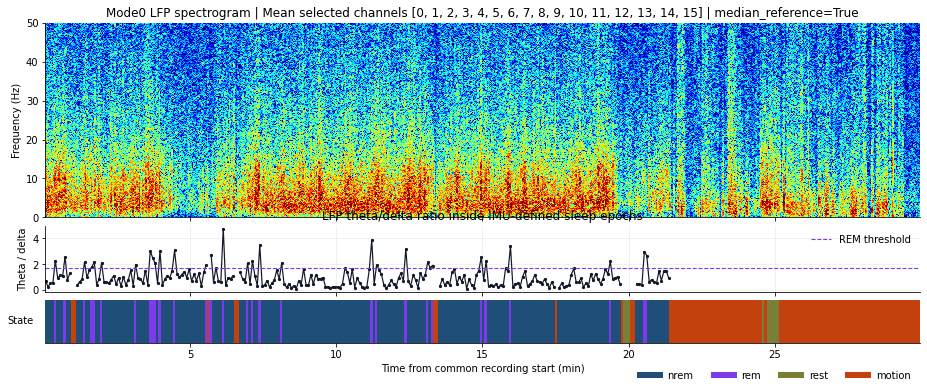

In [61]:
def prepare_lfp_signal(lfp_matrix, cfg):
    channels = sorted({int(ch) for ch in cfg["selected_lfp_channels"]})
    if not channels:
        raise ValueError("selected_lfp_channels must not be empty.")
    if max(channels) >= lfp_matrix.shape[0] or min(channels) < 0:
        raise ValueError(f"Selected channels {channels} exceed available channels {lfp_matrix.shape[0]}.")

    data = np.asarray(lfp_matrix, dtype=float)
    if cfg["median_reference"]:
        data = data - np.median(data, axis=0, keepdims=True)

    selected = data[channels]
    if cfg["lfp_display_mode"] == "mean_selected":
        display = np.mean(selected, axis=0)
        label = f"Mean selected channels {channels}"
    elif cfg["lfp_display_mode"] == "single":
        ch = int(cfg["lfp_single_display_channel"])
        if ch not in channels:
            raise ValueError("lfp_single_display_channel must be included in selected_lfp_channels.")
        display = data[ch]
        label = f"Ch{ch}"
    else:
        raise ValueError("lfp_display_mode must be 'mean_selected' or 'single'.")
    return display, label, selected


def compute_spectrogram(x, fs, cfg):
    nperseg = max(8, int(round(cfg["spectrogram_window_s"] * fs)))
    noverlap = int(round(cfg["spectrogram_overlap_s"] * fs))
    noverlap = min(noverlap, nperseg - 1)
    freqs, times, pxx = signal.spectrogram(
        x,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="density",
        mode="psd",
    )
    return freqs, times, pxx


def state_at_times(query_times_s, state_result):
    starts = state_result["starts_s"]
    stops = state_result["stops_s"]
    states = state_result["states"]
    out = np.full(len(query_times_s), "unknown", dtype=object)
    for idx, t in enumerate(query_times_s):
        hit = np.where((starts <= t) & (t < stops))[0]
        if hit.size:
            out[idx] = states[hit[0]]
    return out


def add_state_background(ax, state_result, alpha=0.18):
    for start_s, stop_s, state in zip(state_result["starts_s"], state_result["stops_s"], state_result["states"]):
        ax.axvspan(start_s / 60.0, stop_s / 60.0, color=STATE_COLORS[state], alpha=alpha, linewidth=0)


def spectrogram_color_limits(spec_db, cfg):
    finite = spec_db[np.isfinite(spec_db)]
    if finite.size == 0:
        return None, None
    vmin = np.nanpercentile(finite, cfg["spectrogram_vmin_percentile"])
    vmax = np.nanpercentile(finite, cfg["spectrogram_vmax_percentile"])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
        return None, None
    return vmin, vmax


def lfp_band_power_for_epoch(trace, time_s, fs, start_s, stop_s, band_hz, welch_window_s):
    mask = (time_s >= start_s) & (time_s < stop_s)
    if np.sum(mask) < max(8, int(round(fs))):
        return np.nan
    segment = np.asarray(trace[mask], dtype=float)
    segment = segment - np.nanmean(segment)
    if not np.all(np.isfinite(segment)):
        segment = np.nan_to_num(segment, nan=0.0)
    nperseg = min(segment.size, max(8, int(round(welch_window_s * fs))))
    noverlap = min(nperseg // 2, nperseg - 1)
    f_epoch, pxx_epoch = signal.welch(segment, fs=fs, nperseg=nperseg, noverlap=noverlap, scaling="density")
    band_mask = (f_epoch >= band_hz[0]) & (f_epoch <= band_hz[1])
    if np.sum(band_mask) < 2:
        return np.nan
    return float(np.trapz(pxx_epoch[band_mask], f_epoch[band_mask]))


def classify_sleep_stages_from_lfp(trace, time_s, fs, state_result, cfg):
    base_states = np.asarray(state_result.get("imu_states", state_result["states"]), dtype=object)
    refined_states = base_states.copy()
    delta_power = np.full(base_states.shape, np.nan, dtype=float)
    theta_power = np.full(base_states.shape, np.nan, dtype=float)
    theta_delta_ratio = np.full(base_states.shape, np.nan, dtype=float)

    sleep_idx = np.where(base_states == "sleep")[0]
    if sleep_idx.size == 0:
        state_result["lfp_sleep_stage_note"] = "No IMU-defined sleep epochs; NREM/REM scoring skipped."
        return state_result

    for idx in sleep_idx:
        delta_power[idx] = lfp_band_power_for_epoch(
            trace,
            time_s,
            fs,
            state_result["starts_s"][idx],
            state_result["stops_s"][idx],
            cfg["sleep_stage_delta_band_hz"],
            cfg["sleep_stage_welch_window_s"],
        )
        theta_power[idx] = lfp_band_power_for_epoch(
            trace,
            time_s,
            fs,
            state_result["starts_s"][idx],
            state_result["stops_s"][idx],
            cfg["sleep_stage_theta_band_hz"],
            cfg["sleep_stage_welch_window_s"],
        )
    theta_delta_ratio = theta_power / (delta_power + 1e-18)
    valid_sleep_idx = sleep_idx[np.isfinite(theta_delta_ratio[sleep_idx])]

    refined_states[sleep_idx] = "nrem"
    rem_threshold = cfg["manual_rem_theta_delta_threshold"]
    if valid_sleep_idx.size >= int(cfg["min_sleep_epochs_for_rem_scoring"]):
        if rem_threshold is None:
            rem_threshold = float(np.nanquantile(theta_delta_ratio[valid_sleep_idx], cfg["rem_theta_delta_quantile"]))
        rem_idx = valid_sleep_idx[theta_delta_ratio[valid_sleep_idx] >= rem_threshold]
        refined_states[rem_idx] = "rem"
        note = "REM scored as high theta/delta within IMU-defined sleep."
    else:
        rem_threshold = np.nan
        note = "Too few valid sleep epochs for REM thresholding; all sleep epochs labeled NREM."

    state_result["states"] = refined_states
    state_result["lfp_delta_power"] = delta_power
    state_result["lfp_theta_power"] = theta_power
    state_result["lfp_theta_delta_ratio"] = theta_delta_ratio
    state_result["rem_theta_delta_threshold"] = rem_threshold
    state_result["lfp_sleep_stage_note"] = note
    return state_result


lfp_display, lfp_display_label, lfp_selected = prepare_lfp_signal(lfp_clean, CONFIG)
freqs, spec_t_local_s, spec_pxx = compute_spectrogram(lfp_display, lfp["fs"], CONFIG)
spec_t_s = (lfp["time_s_abs"][0] - common_start_s) + spec_t_local_s
freq_mask = freqs <= CONFIG["lfp_fmax_hz"]
spec_db = 10.0 * np.log10(spec_pxx[freq_mask] + 1e-18)
vmin, vmax = spectrogram_color_limits(spec_db, CONFIG)

state_result = classify_sleep_stages_from_lfp(lfp_display, lfp_t_s, lfp["fs"], state_result, CONFIG)
if np.any(np.isin(state_result["states"], ["nrem", "rem"])):
    STATE_ORDER = ["nrem", "rem", "rest", "motion"]
    STATE_TO_CODE = {state: idx for idx, state in enumerate(STATE_ORDER)}
else:
    STATE_ORDER = ["sleep", "rest", "motion"]
    STATE_TO_CODE = {state: idx for idx, state in enumerate(STATE_ORDER)}

print(f"Sleep staging note: {state_result['lfp_sleep_stage_note']}")
if "rem_theta_delta_threshold" in state_result and np.isfinite(state_result["rem_theta_delta_threshold"]):
    print(f"REM theta/delta threshold: {state_result['rem_theta_delta_threshold']:.6g}")
for state in STATE_ORDER:
    n_epochs = int(np.sum(state_result["states"] == state))
    duration_min = n_epochs * CONFIG["activity_step_s"] / 60.0
    print(f"{state:>6}: {n_epochs:5d} epochs | approx {duration_min:.2f} min")

fig, axes = plt.subplots(
    3,
    1,
    figsize=(13.5, 6.0),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 0.34, CONFIG["spectrogram_state_bar_height"]], "hspace": 0.08},
)
im = axes[0].pcolormesh(
    seconds_to_minutes(spec_t_s),
    freqs[freq_mask],
    spec_db,
    shading="auto",
    cmap=CONFIG["spectrogram_cmap"],
    vmin=vmin,
    vmax=vmax,
    rasterized=True,
)
axes[0].set_facecolor("#001a5a")
axes[0].set_ylabel("Frequency (Hz)")
axes[0].set_title(f"Mode0 LFP spectrogram | {lfp_display_label} | median_reference={CONFIG['median_reference']}")
axes[0].set_ylim(0, CONFIG["lfp_fmax_hz"])
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
if CONFIG["spectrogram_show_colorbar"]:
    fig.colorbar(im, ax=axes[0], label="PSD (dB/Hz)")

theta_delta_ratio = state_result.get("lfp_theta_delta_ratio", np.full_like(state_result["centers_s"], np.nan, dtype=float))
sleep_ratio_mask = np.isin(state_result.get("imu_states", state_result["states"]), ["sleep"])
ratio_to_plot = np.where(sleep_ratio_mask, theta_delta_ratio, np.nan)
axes[1].plot(seconds_to_minutes(state_result["centers_s"]), ratio_to_plot, color="#111827", lw=1.2, marker="o", ms=2.2)
if "rem_theta_delta_threshold" in state_result and np.isfinite(state_result["rem_theta_delta_threshold"]):
    axes[1].axhline(state_result["rem_theta_delta_threshold"], color=STATE_COLORS["rem"], ls="--", lw=1.1, label="REM threshold")
    axes[1].legend(loc="upper right", frameon=False)
axes[1].set_ylabel("Theta / delta")
axes[1].set_title("LFP theta/delta ratio inside IMU-defined sleep epochs")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(alpha=0.22)

spec_states = state_at_times(spec_t_s, state_result)
state_codes = np.asarray([STATE_TO_CODE.get(state, np.nan) for state in spec_states], dtype=float)
state_cmap = ListedColormap([STATE_COLORS[state] for state in STATE_ORDER])
state_norm = BoundaryNorm(np.arange(-0.5, len(STATE_ORDER) + 0.5), state_cmap.N)
axes[2].imshow(
    state_codes[np.newaxis, :],
    aspect="auto",
    interpolation="nearest",
    origin="lower",
    cmap=state_cmap,
    norm=state_norm,
    extent=[seconds_to_minutes(spec_t_s[0]), seconds_to_minutes(spec_t_s[-1]), 0, 1],
)
axes[2].set_yticks([])
axes[2].set_ylabel("State", rotation=0, labelpad=25, va="center")
axes[2].set_xlabel("Time from common recording start (min)")
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)
axes[2].spines["left"].set_visible(False)
handles = [plt.Line2D([0], [0], color=STATE_COLORS[state], lw=6, label=state) for state in STATE_ORDER]
axes[2].legend(handles=handles, loc="upper right", ncol=4, frameon=False, bbox_to_anchor=(1.0, -0.45))
fig.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.18, hspace=0.08)
plt.show()


## State-Wise LFP Spectrum

This cell assigns each LFP spectrogram time bin to the nearest state epoch, then averages spectral power within each state. If sleep epochs were found, the state labels are the LFP-refined `nrem`, `rem`, `rest`, and `motion`; otherwise they remain `sleep`, `rest`, and `motion`.

Parameters inherited from earlier cells:
- `STATE_ORDER` and `STATE_COLORS`: control state order and plot colors.
- `lfp_fmax_hz`: controls the frequency range shown here because this plot reuses the spectrogram frequency mask.
- `median_reference`, `selected_lfp_channels`, and `lfp_display_mode`: affect the LFP signal used to compute the spectrogram and therefore this state-wise spectrum.

If a state has no epochs in the current recording, that state is skipped in the plotted average.


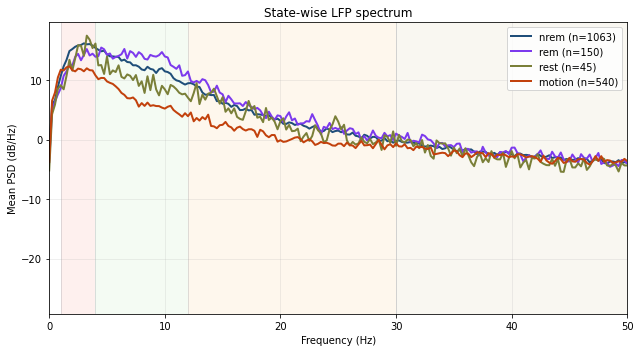

In [62]:
spec_states = state_at_times(spec_t_s, state_result)

fig, ax = plt.subplots(figsize=(9, 5))
band_bg_colors = plt.cm.Pastel1(np.linspace(0.05, 0.95, max(len(CONFIG["lfp_bands"]), 2)))
for idx, (band_name, f_low, f_high) in enumerate(CONFIG["lfp_bands"]):
    left = max(0.0, float(f_low))
    right = min(float(f_high), float(CONFIG["lfp_fmax_hz"]))
    if right <= left:
        continue
    ax.axvspan(left, right, color=band_bg_colors[idx % len(band_bg_colors)], alpha=0.20, lw=0, zorder=0)
    ax.axvline(left, color="#6b7280", lw=0.6, alpha=0.35, zorder=1)
ax.axvline(float(CONFIG["lfp_fmax_hz"]), color="#6b7280", lw=0.6, alpha=0.35, zorder=1)
for state in STATE_ORDER:
    mask = spec_states == state
    if not np.any(mask):
        continue
    mean_psd = np.nanmean(spec_pxx[:, mask], axis=1)
    ax.plot(freqs, 10.0 * np.log10(mean_psd + 1e-18), lw=2, color=STATE_COLORS[state], label=f"{state} (n={np.sum(mask)})")
ax.set_xlim(0, CONFIG["lfp_fmax_hz"])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Mean PSD (dB/Hz)")
ax.set_title("State-wise LFP spectrum")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


## LFP Band Energy Aligned To IMU State

This cell converts the spectrogram into frequency-band power traces, smooths them, and plots those traces on the same timeline as the IMU-derived state labels.

Parameters controlled by `CONFIG`:
- `lfp_bands`: list of `(name, low_hz, high_hz)` bands to summarize. Edit this to add, remove, or rename bands.
- `band_power_smooth_s`: moving-average smoothing duration for band-power traces. Set to `0` or a very small value for minimal smoothing.
- `lfp_fmax_hz`: indirectly limits which frequency bins are available from the spectrogram.

The background shading marks `sleep`, `rest`, and `motion` epochs, so you can visually check whether band energy changes track behavior state.


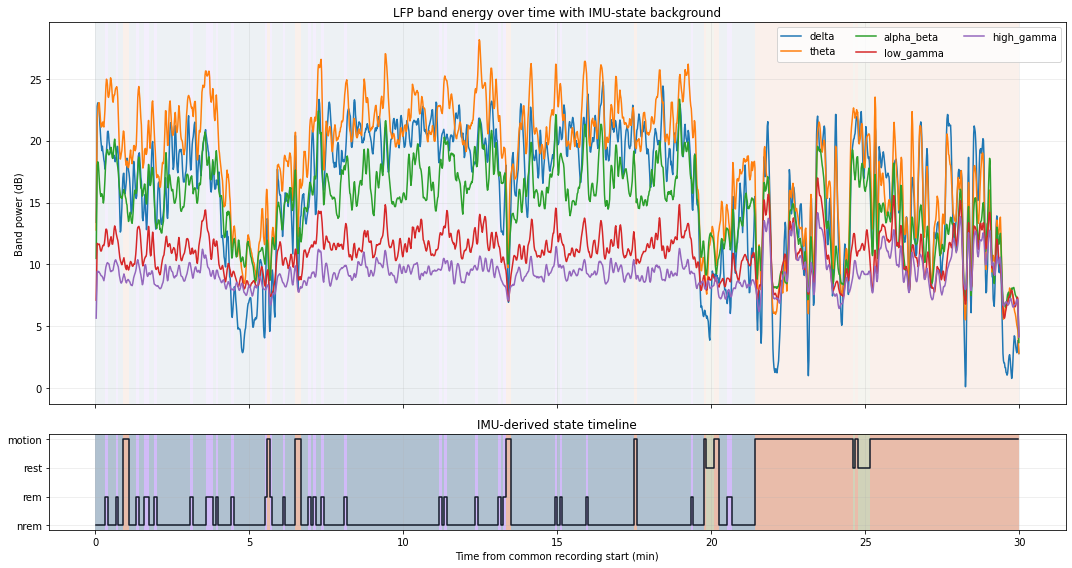

In [63]:
def smooth_trace_by_seconds(trace, spec_t_s, smooth_s):
    trace = np.asarray(trace, dtype=float)
    if smooth_s <= 0 or trace.size < 3:
        return trace
    dt = float(np.nanmedian(np.diff(spec_t_s)))
    win = int(round(smooth_s / dt))
    if win <= 1:
        return trace
    if win % 2 == 0:
        win += 1
    kernel = np.ones(win, dtype=float) / float(win)
    return np.convolve(trace, kernel, mode="same")


band_power = {}
for band_name, f_low, f_high in CONFIG["lfp_bands"]:
    mask = (freqs >= f_low) & (freqs < f_high)
    if not np.any(mask):
        band_power[band_name] = np.full(spec_t_s.shape, np.nan)
        continue
    power = np.trapz(spec_pxx[mask], freqs[mask], axis=0)
    band_power[band_name] = smooth_trace_by_seconds(10.0 * np.log10(power + 1e-18), spec_t_s, CONFIG["band_power_smooth_s"])

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [4, 1]})
for band_name, trace in band_power.items():
    axes[0].plot(seconds_to_minutes(spec_t_s), trace, lw=1.5, label=band_name)
add_state_background(axes[0], state_result, alpha=0.08)
axes[0].set_ylabel("Band power (dB)")
axes[0].set_title("LFP band energy over time with IMU-state background")
axes[0].legend(loc="upper right", ncol=3)
axes[0].grid(alpha=0.25)

state_codes = np.asarray([STATE_TO_CODE[s] for s in state_result["states"]], dtype=float)
axes[1].step(seconds_to_minutes(state_result["centers_s"]), state_codes, where="mid", color="#111827", lw=1.5)
add_state_background(axes[1], state_result, alpha=0.35)
axes[1].set_yticks([STATE_TO_CODE[s] for s in STATE_ORDER])
axes[1].set_yticklabels(STATE_ORDER)
axes[1].set_xlabel("Time from common recording start (min)")
axes[1].set_title("IMU-derived state timeline")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Optional Export

This cell optionally writes a compact HDF5 cache containing cleaned LFP/sensor data, IMU state labels, LFP-refined sleep-stage labels, spectrogram bins, and band-power traces for downstream analysis.

Parameters to edit in this cell:
- `EXPORT_H5`: set to `True` to save the cache; default is `False` to avoid writing files accidentally.
- `export_path`: output HDF5 path.

The exported file is useful when you want to reuse the expensive preprocessing results without rerunning EDF loading and spectrogram calculation.


In [64]:
EXPORT_H5 = False
EXPORT_PATH = MODE0_DIR / "mode0_lfp_sensor_state_analysis_cache.h5"

if EXPORT_H5:
    with h5py.File(EXPORT_PATH, "w") as h5:
        h5.attrs["lfp_path"] = str(CONFIG["lfp_path"])
        h5.attrs["sensor_path"] = str(CONFIG["sensor_path"])
        h5.attrs["median_reference"] = bool(CONFIG["median_reference"])
        h5.create_dataset("lfp_time_s", data=lfp_t_s, compression="gzip")
        h5.create_dataset("sensor_time_s", data=sensor_t_s, compression="gzip")
        h5.create_dataset("lfp_clean", data=lfp_clean, compression="gzip")
        h5.create_dataset("sensor_clean", data=sensor_clean, compression="gzip")
        h5.create_dataset("state_epoch_starts_s", data=state_result["starts_s"])
        h5.create_dataset("state_epoch_stops_s", data=state_result["stops_s"])
        h5.create_dataset("state_codes", data=np.asarray([STATE_TO_CODE[s] for s in state_result["states"]], dtype=int))
        h5.create_dataset("imu_state_codes", data=np.asarray([{ "sleep": 0, "rest": 1, "motion": 2 }[s] for s in state_result["imu_states"]], dtype=int))
        if "lfp_theta_delta_ratio" in state_result:
            h5.create_dataset("lfp_sleep_delta_power", data=state_result["lfp_delta_power"])
            h5.create_dataset("lfp_sleep_theta_power", data=state_result["lfp_theta_power"])
            h5.create_dataset("lfp_sleep_theta_delta_ratio", data=state_result["lfp_theta_delta_ratio"])
            h5.attrs["rem_theta_delta_threshold"] = float(state_result.get("rem_theta_delta_threshold", np.nan))
        h5.create_dataset("spectrogram_time_s", data=spec_t_s)
        h5.create_dataset("spectrogram_freq_hz", data=freqs)
        h5.create_dataset("spectrogram_psd", data=spec_pxx, compression="gzip")
        grp = h5.create_group("band_power")
        for band_name, trace in band_power.items():
            grp.create_dataset(band_name, data=trace)
    print(f"Saved cache to {EXPORT_PATH}")
else:
    print("EXPORT_H5 is False; no file was written.")


EXPORT_H5 is False; no file was written.
